1. Who is more likely to miss appointments?

2. Does waiting time matter?

3. Does SMS status correlate with no-show?

4. Does age matter?

5. Does appointment weekday matter?

6. Does appointment time matter?

7. Does neighbourhood matter?

8. Do chronic-condition indicators relate to no-show?

9. Are there interactions between features?

10. Which features should actually enter the ML model?

# Healthcare Appointment No-Show Prediction

## 02 - Exploratory Data Analysis

### Objective

Analyze the cleaned healthcare appointment dataset to understand:

- Target variable distribution
- Patient demographics
- Appointment timing
- Waiting time
- SMS reminders
- Medical-condition indicators
- Neighbourhood patterns
- Relationships between features and appointment no-shows

The findings from this analysis will guide feature engineering and model development.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv('../data/raw/HealthCare.csv')

In [34]:
df['ScheduledDay'] = pd.to_datetime(
    df['ScheduledDay'],
    utc = True
)

df['AppointmentDay'] = pd.to_datetime(
    df['AppointmentDay'],
    utc = True
)

df['Age'] = df['Age'].mask(
    (df['Age']<0) | (df['Age'] > 100)
)

df['WaitingDays'] = (
    df['AppointmentDay'].dt.normalize()
    - df['ScheduledDay'].dt.normalize()
).dt.days

df['WaitingDays'] = df['WaitingDays'].mask(
    df['WaitingDays'] < 0
)

In [35]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,WaitingDays
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62.0,JARDIM DA PENHA,0,1,0,0,0,0,No,0.0
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56.0,JARDIM DA PENHA,0,0,0,0,0,0,No,0.0
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62.0,MATA DA PRAIA,0,0,0,0,0,0,No,0.0
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8.0,PONTAL DE CAMBURI,0,0,0,0,0,0,No,0.0
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56.0,JARDIM DA PENHA,0,1,1,0,0,0,No,0.0


In [36]:
print("Shape:", df.shape)
print("Missing Age:", df["Age"].isna().sum())
print("Missing WaitingDays:", df["WaitingDays"].isna().sum())

Shape: (110527, 15)
Missing Age: 8
Missing WaitingDays: 5


In [37]:
df['No-show'] = df['No-show'].map({
    'No':0,
    'Yes':1
})

In [38]:
df['No-show'].value_counts()

No-show
0    88208
1    22319
Name: count, dtype: int64

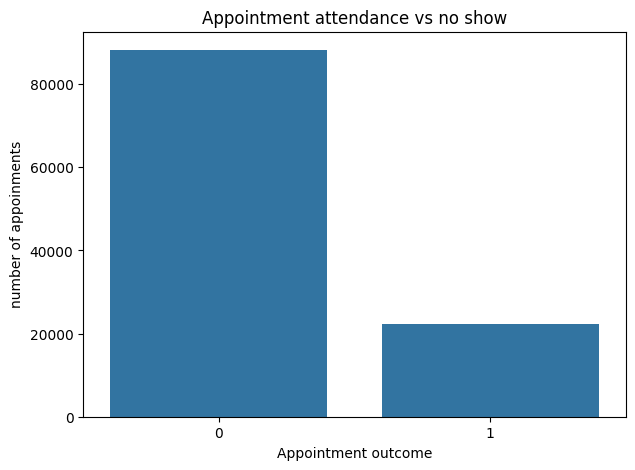

In [39]:
plt.figure(figsize = (7, 5))

sns.countplot(
    data = df,
    x = 'No-show'
)

plt.title('Appointment attendance vs no show')
plt.xlabel('Appointment outcome')
plt.ylabel('number of appoinments')

plt.show()

In [40]:
# calculate the percentage 

target_percentage = (
    df['No-show']
    .value_counts(normalize = True)
    .mul(100)
    .round(2)
)

target_percentage

No-show
0    79.81
1    20.19
Name: proportion, dtype: float64

In [41]:
# age distribution 

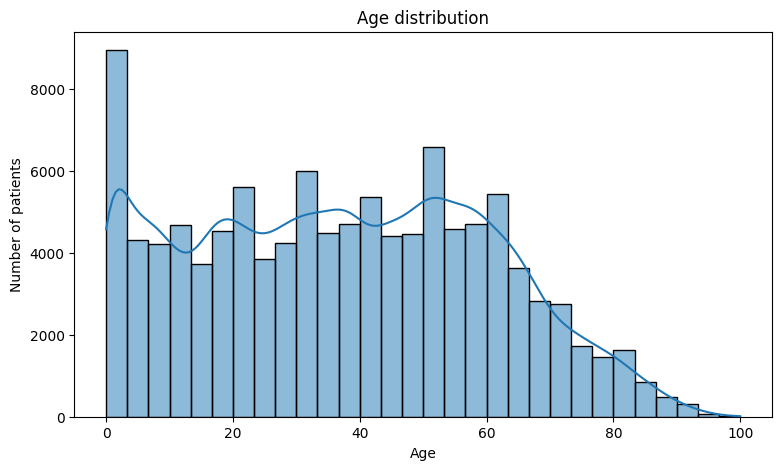

In [42]:
plt.figure(figsize = (9, 5))

sns.histplot(
    data = df,
    x = 'Age',
    bins = 30,
    kde = True
)

plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Number of patients')

plt.show()

In [43]:
df['Age'].describe()

count    110519.000000
mean         37.084519
std          23.103165
min           0.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         100.000000
Name: Age, dtype: float64

In [44]:
# age vs no-show

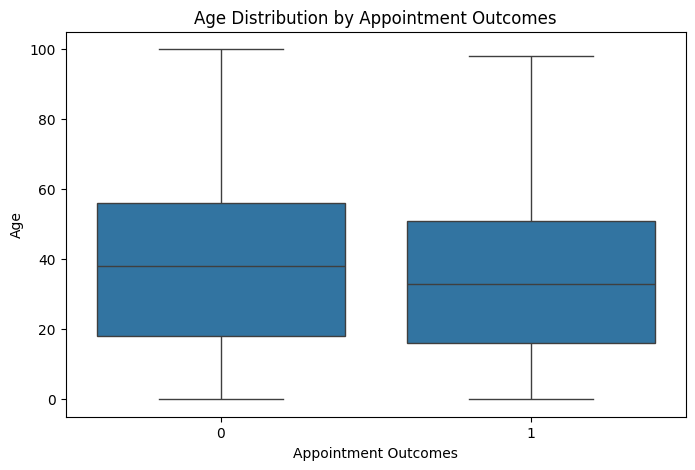

In [45]:
plt.figure(figsize = (8, 5))

sns.boxplot(
    data = df,
    x = 'No-show',
    y = 'Age'
)

plt.title('Age Distribution by Appointment Outcomes')
plt.xlabel('Appointment Outcomes')
plt.ylabel('Age')

plt.show()

In [46]:
# create age group

In [47]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins = [-1, 12, 18, 30, 45, 60, 75, 100],
    labels = [
        'Child',
        'Teen',
        'young Adult',
        'Adult',
        'Middle age',
        'senior',
        '75+'
    ]
)

In [48]:
age_no_show = pd.crosstab(
    df['AgeGroup'],
    df['No-show'],
    normalize = 'index'
) * 100

age_no_show

No-show,0,1
AgeGroup,,
Child,79.525575,20.474425
Teen,73.946360,26.053640
young Adult,75.287802,24.712198
Adult,78.628040,21.371960
Middle age,82.177833,17.822167
senior,85.135699,14.864301
75+,83.899721,16.100279


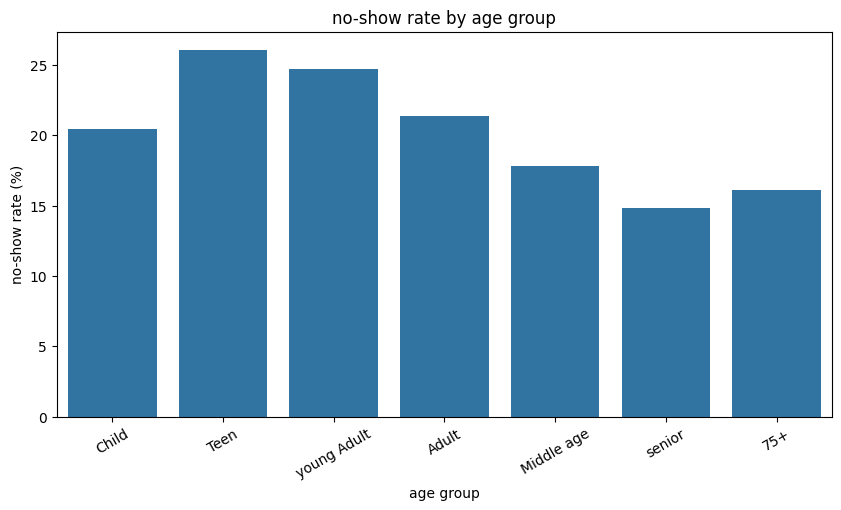

In [49]:
plt.figure(figsize = (10,5))

sns.barplot(
    x = age_no_show.index,
    y = age_no_show[1]
)

plt.title('no-show rate by age group')
plt.xlabel('age group')
plt.ylabel('no-show rate (%)')
plt.xticks(rotation=30)

plt.show()

In [50]:
# gender vs no show

In [51]:
gender_no_show = pd.crosstab(
    df['Gender'],
    df['No-show'],
    normalize = 'index'
) * 100

gender_no_show

No-show,0,1
Gender,,
F,79.685412,20.314588
M,80.032052,19.967948


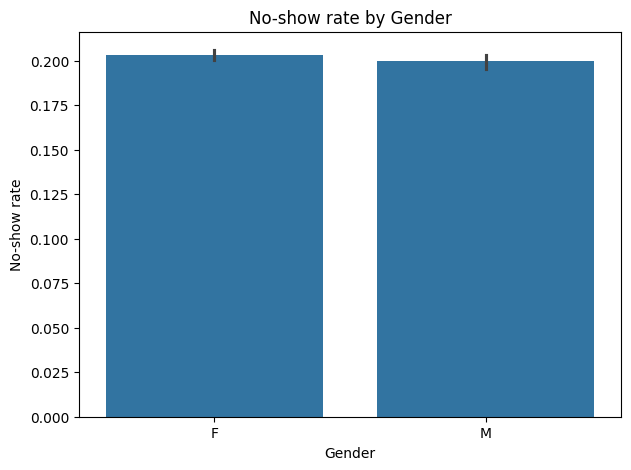

In [52]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data = df,
    x = 'Gender',
    y = 'No-show',
)

plt.title('No-show rate by Gender')
plt.xlabel('Gender')
plt.ylabel('No-show rate')

plt.show()

In [53]:
# Waiting Days Distribution 

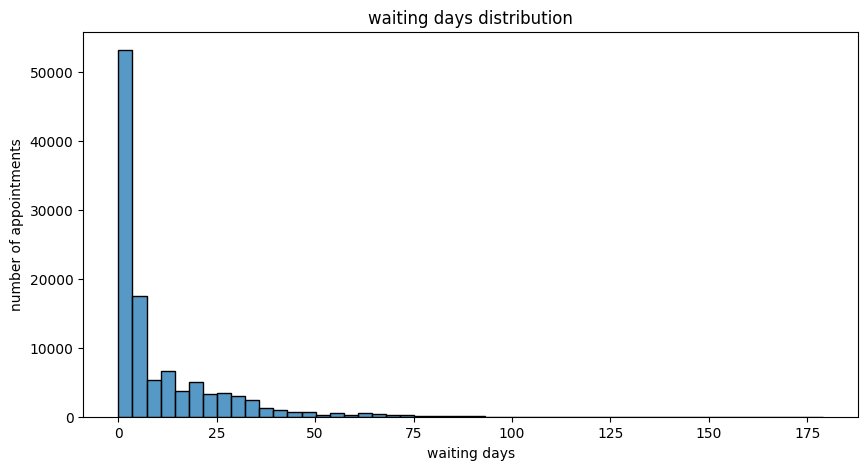

In [54]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data = df,
    x = 'WaitingDays',
    bins = 50
)

plt.title('waiting days distribution')
plt.xlabel('waiting days')
plt.ylabel('number of appointments')

plt.show()


In [55]:
df['WaitingDays'].describe()

count    110522.000000
mean         10.184253
std          15.255115
min           0.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: WaitingDays, dtype: float64

In [56]:
# waitingDays vs No-show

In [57]:
df['WaitingGroup'] = pd.cut(
    df['WaitingDays'],
    bins = [-1, 0, 3, 7, 14, 30, 60, 180],
    labels=[
        'same Day',
        '1-3 Days',
        '4-7 Days',
        '8-14 Days',
        '15-30 Days',
        '31-60 Days',
        '61-180 Days'
    ]
)



In [59]:
waiting_no_show = pd.crosstab(
    df['WaitingGroup'],
    df['No-show'],
    normalize = 'index'
) * 100

In [60]:
waiting_no_show

No-show,0,1
WaitingGroup,,
same Day,95.353059,4.646941
1-3 Days,77.110733,22.889267
4-7 Days,74.797259,25.202741
8-14 Days,69.530146,30.469854
15-30 Days,67.411203,32.588797
31-60 Days,65.845708,34.154292
61-180 Days,71.551313,28.448687


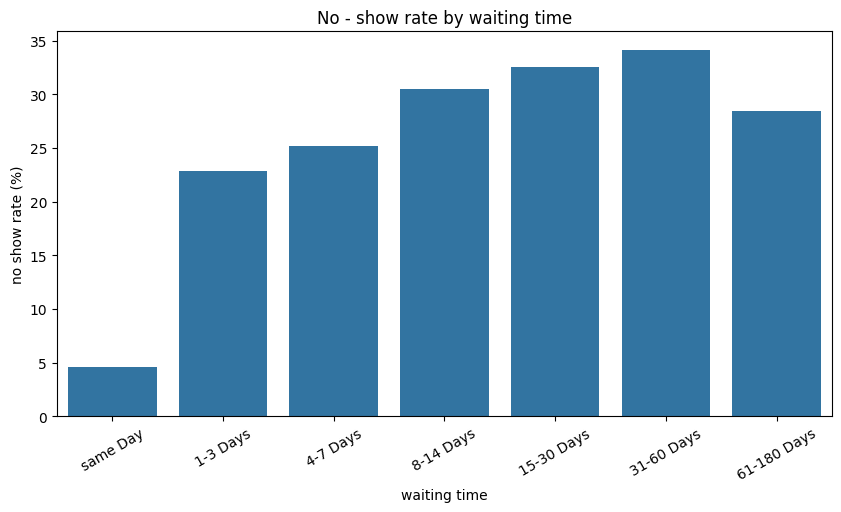

In [62]:
# visualize

plt.figure(figsize=(10, 5))

sns.barplot(
    x = waiting_no_show.index,
    y = waiting_no_show[1]
)

plt.title('No - show rate by waiting time')
plt.xlabel('waiting time')
plt.ylabel('no show rate (%)')
plt.xticks(rotation = 30)
plt.show()

In [63]:
# sms recieved vs no-show

In [64]:
sms_no_show = pd.crosstab(
    df['SMS_received'],
    df['No-show'],
    normalize='index'
) * 100

sms_no_show

No-show,0,1
SMS_received,,
0,83.296689,16.703311
1,72.425455,27.574545


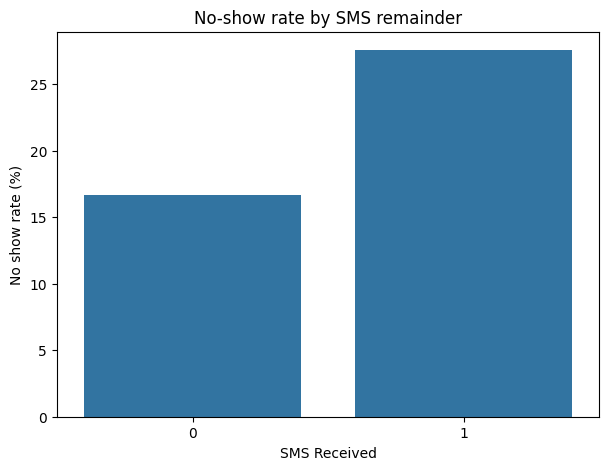

In [67]:
plt.figure(figsize=(7,5))

sns.barplot(
    x = sms_no_show.index,
    y = sms_no_show[1]
)

plt.title('No-show rate by SMS remainder')
plt.xlabel('SMS Received')
plt.ylabel('No show rate (%)')

plt.show()

In [76]:
df['AppointmentDayOfWeek'] = (
    df['AppointmentDay'].dt.day_name()
)

In [77]:
weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

In [78]:
weekday_no_show = pd.crosstab(
    df['AppointmentDayOfWeek'],
    df['No-show'],
    normalize = 'index'
) * 100

weekday_no_show = weekday_no_show.reindex(weekday_order)

weekday_no_show

No-show,0,1
AppointmentDayOfWeek,,
Monday,79.352851,20.647149
Tuesday,79.906396,20.093604
Wednesday,80.310821,19.689179
Thursday,80.645909,19.354091
Friday,78.773858,21.226142
Saturday,76.923077,23.076923
Sunday,NaN,NaN


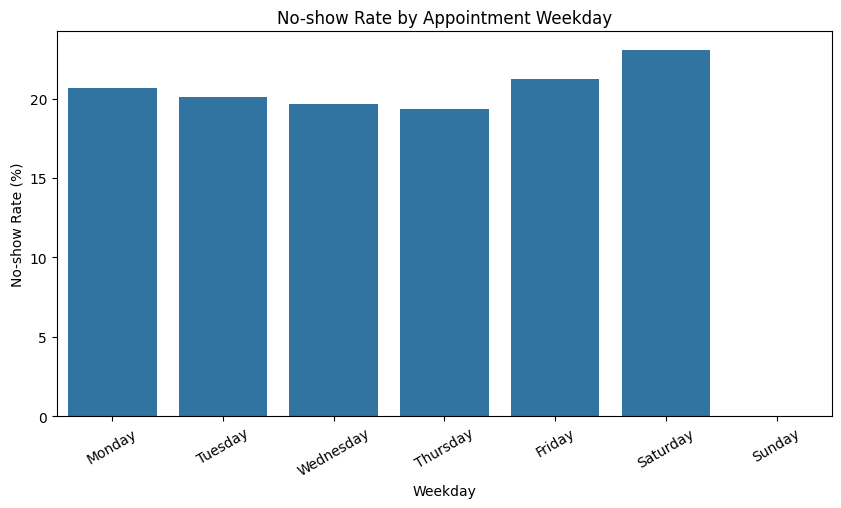

In [79]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=weekday_no_show.index,
    y=weekday_no_show[1]
)

plt.title("No-show Rate by Appointment Weekday")
plt.xlabel("Weekday")
plt.ylabel("No-show Rate (%)")

plt.xticks(rotation=30)

plt.show()

In [80]:
# Appointment hour

In [81]:
df['ScheduledHour'] = df['ScheduledDay'].dt.hour

In [82]:
hour_no_show = pd.crosstab(
    df['ScheduledHour'],
    df['No-show'],
    normalize='index'
) * 100

In [83]:
hour_no_show

No-show,0,1
ScheduledHour,,
6,80.798479,19.201521
7,84.848800,15.151200
8,81.731709,18.268291
9,80.301022,19.698978
10,77.930535,22.069465
11,77.215788,22.784212
12,79.638510,20.361490
13,79.072598,20.927402
14,77.320039,22.679961


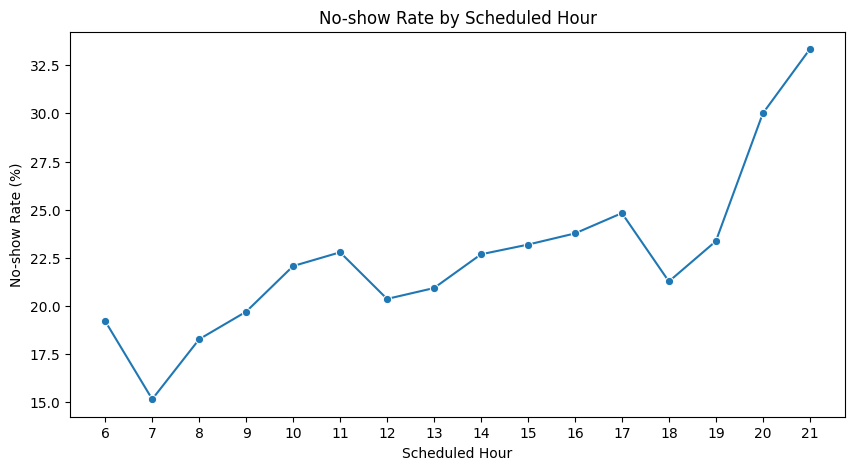

In [84]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    x=hour_no_show.index,
    y=hour_no_show[1],
    marker="o"
)

plt.title("No-show Rate by Scheduled Hour")
plt.xlabel("Scheduled Hour")
plt.ylabel("No-show Rate (%)")
plt.xticks(range(6, 22))

plt.show()

In [85]:
# Medical conditions

In [86]:
medical_features = [
    'Hipertension',
    'Diabetes',
    'Alcoholism'
]

for feature in medical_features:
    result = pd.crosstab(
        df[feature],
        df['No-show'],
        normalize = 'index'
    ) * 100

    print(f'\n{feature}')
    print(result)


Hipertension
No-show               0          1
Hipertension                      
0             79.096319  20.903681
1             82.698041  17.301959

Diabetes
No-show           0          1
Diabetes                      
0         79.637175  20.362825
1         81.996727  18.003273

Alcoholism
No-show             0          1
Alcoholism                      
0           79.805351  20.194649
1           79.851190  20.148810


In [111]:
df["No_show"] = df["No-show"].astype(int)

In [112]:
df[["No-show", "No_show"]].head(10)

,No-show,No_show
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,1,1
7,1,1
8,0,0
9,0,0


In [113]:
df["No_show"].value_counts(dropna=False)

No_show
0    88208
1    22319
Name: count, dtype: int64

In [114]:
df["No_show"].isna().sum()

np.int64(0)

In [115]:
# Neighbourhood

In [120]:
neighbourhood_stats = (
    df.groupby("Neighbourhood")
    .agg(
        Appointments=("No-show", "size"),
        No_show_rate=("No_show", "mean")
    )
    .sort_values("Appointments", ascending=False)
)

neighbourhood_stats["No_show_rate"] = (
    neighbourhood_stats["No_show_rate"] * 100
)

neighbourhood_stats.head(20)

,Appointments,No_show_rate
Neighbourhood,,
JARDIM CAMBURI,7717,18.984061
MARIA ORTIZ,5805,20.999139
RESISTÊNCIA,4431,20.446852
JARDIM DA PENHA,3877,16.275471
ITARARÉ,3514,26.266363
CENTRO,3334,21.085783
TABUAZEIRO,3132,18.295019
SANTA MARTHA,3131,15.841584
JESUS DE NAZARETH,2853,24.395373


In [121]:
# Scholarship

In [122]:
scholarship_rate = (
    df.groupby('Scholarship')['No_show']
    .mean()
    .mul(100)
)

scholarship_rate

Scholarship
0    19.807156
1    23.736304
Name: No_show, dtype: float64

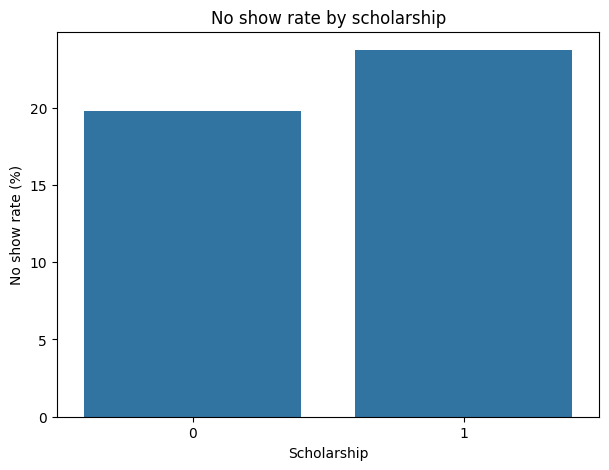

In [123]:
# visualize 

plt.figure(figsize=(7, 5))

sns.barplot(
    x = scholarship_rate.index,
    y = scholarship_rate.values
)

plt.title('No show rate by scholarship')
plt.xlabel('Scholarship')
plt.ylabel('No show rate (%)')
plt.show()

In [124]:
# Handicap

In [136]:
handicap_rate = (
    df.groupby("Handcap")["No_show"]
    .mean()
    .mul(100)
)

handicap_rate

Handcap
0    20.235303
1    17.923604
2    20.218579
3    23.076923
4    33.333333
Name: No_show, dtype: float64

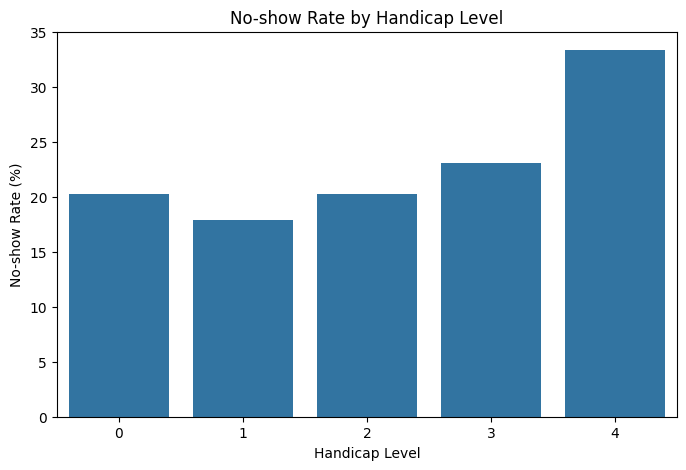

In [137]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=handicap_rate.index,
    y=handicap_rate.values
)

plt.title("No-show Rate by Handicap Level")
plt.xlabel("Handicap Level")
plt.ylabel("No-show Rate (%)")
plt.show()

In [138]:
# Neighbourhood distribution

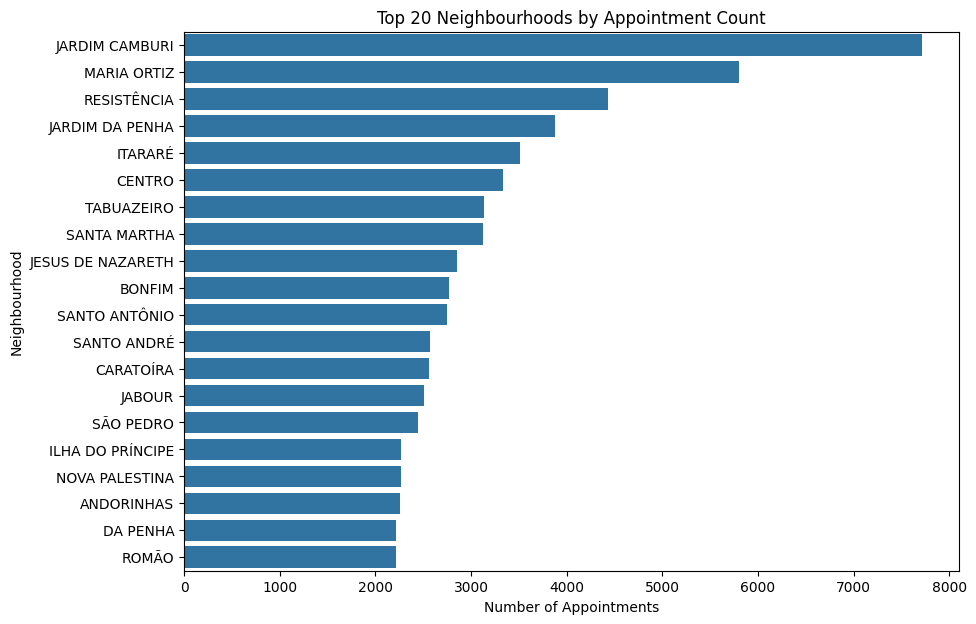

In [139]:
neighbourhood_counts = (
    df["Neighbourhood"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=neighbourhood_counts.values,
    y=neighbourhood_counts.index
)

plt.title("Top 20 Neighbourhoods by Appointment Count")
plt.xlabel("Number of Appointments")
plt.ylabel("Neighbourhood")
plt.show()

In [140]:
# Repeat patients

In [141]:
patient_counts = df["PatientId"].value_counts()

print("Unique patients:", patient_counts.nunique())
print("Patients with multiple appointments:", (patient_counts > 1).sum())
print("Patients with 5+ appointments:", (patient_counts >= 5).sum())

Unique patients: 44
Patients with multiple appointments: 24379
Patients with 5+ appointments: 2617


## EDA Summary

Key findings:

1. The dataset contains a significant class imbalance, with approximately 20% no-show appointments.
2. Age shows differences in no-show rates across age groups.
3. Waiting time is strongly associated with appointment attendance.
4. SMS receipt is associated with different no-show rates, but this relationship should not be interpreted as causal.
5. Gender shows only a small difference in no-show rates.
6. Appointment weekday shows relatively small differences, with very few Saturday observations and no Sunday observations.
7. Scheduled hour shows variation in no-show rates, although some late-hour categories have very few observations.
8. Neighbourhood shows variation in appointment volume and no-show rate.
9. Hypertension, diabetes, and alcoholism show relatively small univariate differences.
10. Patient IDs repeat across appointments, which should be considered when designing model evaluation.